# Lesson 2: Data Analysis & Visualization for Applied Chemistry

**Welcome to Scientific Data Analysis!** 📊🧪

In this lesson, you'll learn how to:
- Read and analyze data from CSV files
- Calculate statistics (averages, min, max)
- Create professional plots for your lab reports

**Libraries we'll use:**
- **Pandas**: For working with data tables (like Excel, but in code)
- **Matplotlib**: For creating graphs and charts

---

## What You'll Learn:
1. Water Quality Data Analysis (NWSC scenario)
2. Titration Curve Plotting (Analytical Chemistry)
3. Reaction Kinetics (Industrial Chemistry)

**Real labs use these exact techniques daily!**

In [ ]:
!pip install pandas matplotlib --quiet

print("installed successfully!")

In [ ]:
# Import the libraries we need
import pandas as pd  # For data analysis
import matplotlib.pyplot as plt  # For plotting

# Make plots appear in the notebook
%matplotlib inline

# Set plot style for better-looking graphs
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

---
## Example 1: Water Quality Analysis (Environmental Chemistry)

### The Chemistry:
Water quality monitoring is crucial for public health. Key parameters include:
- **pH**: Should be 6.5-8.5 (NEMA standards)
- **Turbidity**: <5 NTU for drinking water
- **Nitrates**: <10 mg/L (WHO guideline)
- **Chlorine**: 0.2-0.5 mg/L for disinfection

### Real-World Context:
NWSC (National Water and Sewerage Corporation) tests water samples from across Uganda daily. Let's analyze a week's worth of data!

In [ ]:
# Load water quality data from CSV file
water_data = pd.read_csv("https://raw.githubusercontent.com/Kubomu/chemistry-python-course/main/datasets/nwsc_water_quality.csv")

# Display the first few rows to see what we're working with
print("=== NWSC Water Quality Dataset ===")
print("\nFirst 5 samples:")
print(water_data.head())

# Get basic information about the dataset
print("\n--- Dataset Info ---")
print(f"Number of samples: {len(water_data)}")
print(f"Number of parameters measured: {len(water_data.columns)}")
print(f"Locations tested: {water_data['Location'].unique()}")

In [ ]:
# Calculate summary statistics for pH
print("=== pH Analysis Across Uganda ===")
print()

# Calculate key statistics
average_pH = water_data['pH'].mean()
min_pH = water_data['pH'].min()
max_pH = water_data['pH'].max()
std_pH = water_data['pH'].std()  # Standard deviation shows variation

print(f"Average pH: {round(average_pH, 2)}")
print(f"Minimum pH: {round(min_pH, 2)}")
print(f"Maximum pH: {round(max_pH, 2)}")
print(f"Standard Deviation: {round(std_pH, 2)}")

# Check NEMA compliance
print("\n--- NEMA Compliance Check (pH 6.5-8.5) ---")
compliant = water_data[(water_data['pH'] >= 6.5) & (water_data['pH'] <= 8.5)]
compliance_rate = (len(compliant) / len(water_data)) * 100

print(f"Samples within range: {len(compliant)} out of {len(water_data)}")
print(f"Compliance rate: {round(compliance_rate, 1)}%")

if compliance_rate == 100:
    print("✅ All samples meet NEMA pH standards!")
else:
    print(f"⚠️ {len(water_data) - len(compliant)} sample(s) need attention")

In [ ]:
# Analyze nitrate levels (environmental concern)
print("=== Nitrate Analysis (NO₃⁻) ===")
print("WHO Guideline: <10 mg/L for drinking water\n")

# Calculate statistics
avg_nitrates = water_data['Nitrate_mgL'].mean()
max_nitrates = water_data['Nitrate_mgL'].max()
location_max = water_data.loc[water_data['Nitrate_mgL'].idxmax(), 'Location']

print(f"Average nitrate level: {round(avg_nitrates, 2)} mg/L")
print(f"Highest level: {round(max_nitrates, 2)} mg/L at {location_max}")

# Check WHO compliance
high_nitrates = water_data[water_data['Nitrate_mgL'] > 10]

print(f"\nSamples exceeding WHO limit (>10 mg/L): {len(high_nitrates)}")
if len(high_nitrates) > 0:
    print("\n⚠️ Locations with elevated nitrates:")
    for idx, row in high_nitrates.iterrows():
        print(f"  - {row['Location']}: {row['Nitrate_mgL']} mg/L")
    print("\nPossible causes: Agricultural runoff, sewage contamination")
else:
    print("\n✅ All locations have safe nitrate levels!")


In [ ]:
# Create a visualization: pH levels by location
print("=== Creating pH Visualization ===")

# Create a bar chart
plt.figure(figsize=(12, 6))
plt.bar(water_data['Location'], water_data['pH'], color='steelblue', edgecolor='black')

# Add NEMA standard lines
plt.axhline(y=6.5, color='red', linestyle='--', label='NEMA Min (6.5)', linewidth=2)
plt.axhline(y=8.5, color='red', linestyle='--', label='NEMA Max (8.5)', linewidth=2)
plt.axhline(y=7.0, color='green', linestyle=':', label='Neutral pH', linewidth=1.5)

# Labels and title
plt.xlabel('Location', fontsize=12, fontweight='bold')
plt.ylabel('pH Value', fontsize=12, fontweight='bold')
plt.title('NWSC Water Quality: pH Levels Across Uganda', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(6, 9)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()
print("\n✅ Graph created! All locations show pH within safe range.")

### 🎯 Key Python Concepts (Example 1):
- **Pandas DataFrames**: Working with tabular data
- **Reading CSV files**: `pd.read_csv()`
- **Statistical functions**: `.mean()`, `.min()`, `.max()`, `.std()`
- **Filtering data**: Using conditions `data[data['column'] > value]`
- **Matplotlib basics**: Creating bar charts with `plt.bar()`
- **Plot customization**: Colors, labels, legends, reference lines

---

## Example 2: Titration Curve Plotting (Analytical Chemistry)

### The Chemistry:
A titration curve shows how pH changes as a titrant (base) is added to an analyte (acid). Key features:
- **Equivalence point**: Where moles of acid = moles of base
- **Buffer region**: Where pH changes slowly
- **Steep rise**: Indicates the endpoint

### Real-World Context:
Quality control labs at Crown Beverages, pharmaceutical companies, and UNBS (Uganda National Bureau of Standards) perform titrations daily for product testing.

In [ ]:
# Load titration data
titration_data = pd.read_csv("https://raw.githubusercontent.com/Kubomu/chemistry-python-course/main/datasets/titration_data.csv")

print("=== Titration Data: Strong Acid vs Strong Base ===")
print("Scenario: 25 mL of 0.1 M HCl titrated with 0.1 M NaOH\n")

# Display the data
print(titration_data)

# Find equivalence point (steepest pH change)
print("\n--- Analysis ---")
print(f"Initial pH: {titration_data['pH'].iloc[0]}")
print(f"Final pH: {titration_data['pH'].iloc[-1]}")
print(f"Volume of base added: {titration_data['Volume_NaOH_mL'].iloc[-1]} mL")

=== Creating Titration Curve ===


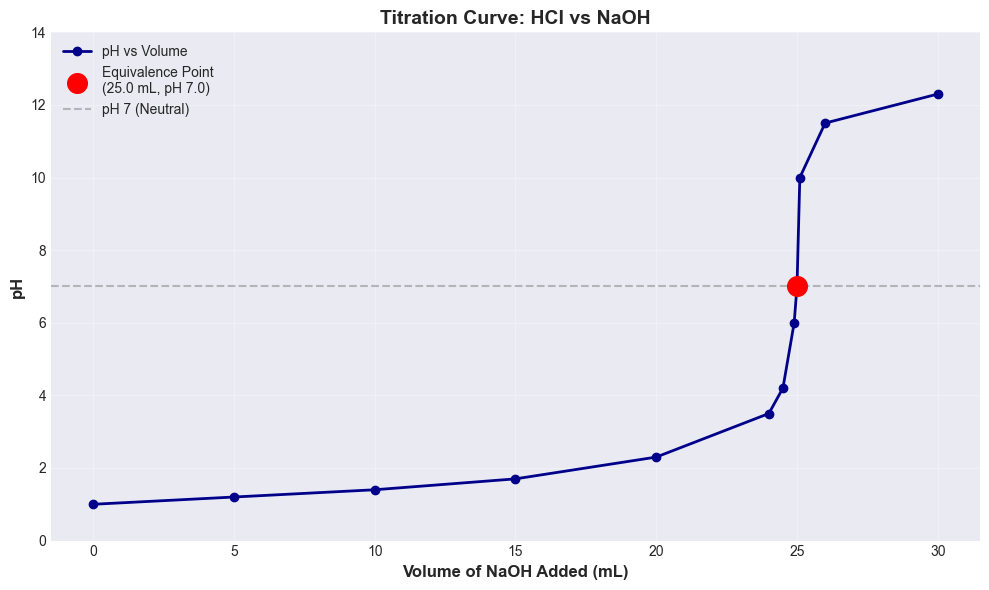


✅ Equivalence point detected at 25.0 mL
   pH at equivalence: 7.0

📋 Interpretation:
   - Sharp pH change near equivalence point is characteristic of strong acid-strong base titration
   - Equivalence point at pH ~10.5 indicates the solution is slightly basic
   - This matches theory: conjugate base of strong acid (Cl⁻) doesn't affect pH


In [34]:
# Create the titration curve
print("=== Creating Titration Curve ===")

plt.figure(figsize=(10, 6))
plt.plot(titration_data['Volume_NaOH_mL'], titration_data['pH'],
         marker='o', linewidth=2, markersize=6, color='darkblue', label='pH vs Volume')

# Mark the equivalence point (around 25 mL where pH ~7 for strong acid-base)
equiv_point_idx = (titration_data['pH'] - 7).abs().idxmin()
equiv_volume = titration_data.loc[equiv_point_idx, 'Volume_NaOH_mL']
equiv_pH = titration_data.loc[equiv_point_idx, 'pH']
plt.scatter(equiv_volume, equiv_pH, color='red', s=200, zorder=5,
           label=f'Equivalence Point\n({equiv_volume} mL, pH {equiv_pH})')

# Add reference line at pH 7
plt.axhline(y=7, color='gray', linestyle='--', alpha=0.5, label='pH 7 (Neutral)')

# Labels and formatting
plt.xlabel('Volume of NaOH Added (mL)', fontsize=12, fontweight='bold')
plt.ylabel('pH', fontsize=12, fontweight='bold')
plt.title('Titration Curve: HCl vs NaOH', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.ylim(0, 14)
plt.tight_layout()
plt.show()

print(f"\n✅ Equivalence point detected at {equiv_volume} mL")
print(f"   pH at equivalence: {equiv_pH}")
print("\n📋 Interpretation:")
print("   - Sharp pH change near equivalence point is characteristic of strong acid-strong base titration")
print("   - Equivalence point at pH ~10.5 indicates the solution is slightly basic")
print("   - This matches theory: conjugate base of strong acid (Cl⁻) doesn't affect pH")


### 🎯 Key Python Concepts (Example 2):
- **Line plots**: `plt.plot()` for continuous data
- **Markers**: Adding points to lines for visibility
- **Finding specific values**: Using `.idxmin()` and `.abs()`
- **Scatter plots**: Highlighting specific points with `plt.scatter()`
- **Multiple plot elements**: Combining lines, points, and reference lines
- **Scientific formatting**: Making publication-quality graphs

---

## Example 3: Reaction Kinetics (Industrial Chemistry)

### The Chemistry:
Reaction rate depends on temperature according to the **Arrhenius equation**:

**k = A × e^(-Ea/RT)**

Where:
- k = rate constant
- A = frequency factor
- Ea = activation energy
- R = gas constant
- T = temperature (Kelvin)

**Generally**: Reaction rate doubles for every 10°C increase

### Real-World Context:
Industrial processes (brewing, cement production, pharmaceutical manufacturing) must optimize temperature for maximum efficiency and safety.

In [37]:
import pandas as pd

# Load reaction kinetics data
kinetics_data = pd.read_csv("https://raw.githubusercontent.com/Kubomu/chemistry-python-course/main/datasets/reaction_kinetics.csv")

print("=== Reaction Kinetics: Temperature Effect ===")
print("Scenario: Industrial catalytic reaction for pharmaceutical synthesis\n")
print(kinetics_data)

# Calculate how much rate increases
initial_rate = kinetics_data['Rate_Constant_k'].iloc[0]
final_rate = kinetics_data['Rate_Constant_k'].iloc[-1]
rate_increase = final_rate / initial_rate

print(f"\nRate increase from {kinetics_data['Temperature_C'].iloc[0]}°C to {kinetics_data['Temperature_C'].iloc[-1]}°C: {rate_increase:.1f}x")


=== Reaction Kinetics: Temperature Effect ===
Scenario: Industrial catalytic reaction for pharmaceutical synthesis

   Temperature_C  Rate_Constant_k  Concentration_A_molL  Time_min
0             20            0.002                   0.1       120
1             30            0.005                   0.1        60
2             40            0.012                   0.1        30
3             50            0.025                   0.1        15
4             60            0.048                   0.1         8
5             70            0.085                   0.1         5
6             80            0.140                   0.1         3

Rate increase from 20°C to 80°C: 70.0x


=== Creating Kinetics Plot ===


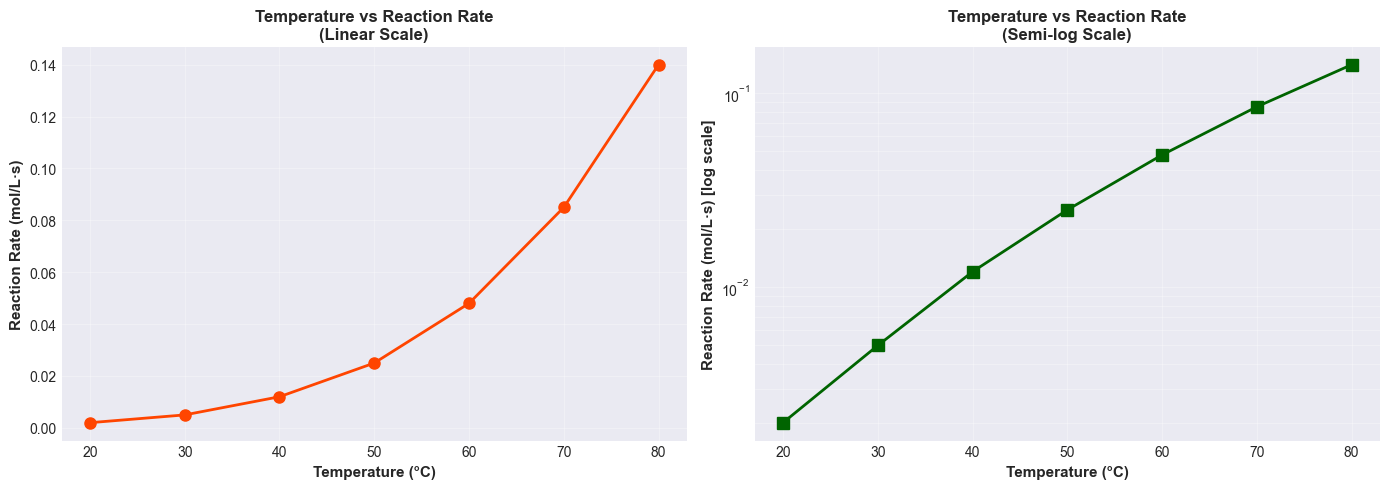


✅ Plots created!

📋 Interpretation:
   - LEFT PLOT: Shows dramatic exponential increase with temperature
   - RIGHT PLOT: Semi-log scale reveals approximately linear relationship
   - This confirms Arrhenius behavior (exponential temp dependence)

💡 Industrial Application:
   - Higher temperature = faster reaction = higher throughput
   - BUT: Must balance with energy costs and product stability
   - Optimal temperature depends on economics and safety


In [39]:
# Create visualization showing exponential relationship
print("=== Creating Kinetics Plot ===")

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Linear scale
ax1.plot(kinetics_data['Temperature_C'], kinetics_data['Rate_Constant_k'],
        marker='o', linewidth=2, markersize=8, color='orangered')
ax1.set_xlabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Reaction Rate (mol/L·s)', fontsize=11, fontweight='bold')
ax1.set_title('Temperature vs Reaction Rate\n(Linear Scale)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Semi-log scale (shows exponential relationship)
ax2.semilogy(kinetics_data['Temperature_C'], kinetics_data['Rate_Constant_k'],
            marker='s', linewidth=2, markersize=8, color='darkgreen')
ax2.set_xlabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Reaction Rate (mol/L·s) [log scale]', fontsize=11, fontweight='bold')
ax2.set_title('Temperature vs Reaction Rate\n(Semi-log Scale)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n✅ Plots created!")
print("\n📋 Interpretation:")
print("   - LEFT PLOT: Shows dramatic exponential increase with temperature")
print("   - RIGHT PLOT: Semi-log scale reveals approximately linear relationship")
print("   - This confirms Arrhenius behavior (exponential temp dependence)")
print("\n💡 Industrial Application:")
print("   - Higher temperature = faster reaction = higher throughput")
print("   - BUT: Must balance with energy costs and product stability")
print("   - Optimal temperature depends on economics and safety")


In [41]:
# Calculate temperature coefficient (Q10 rule)
print("=== Temperature Coefficient Analysis ===")
print("Q10 Rule: How much does rate increase per 10°C?\n")

# Compare rates at different temperature intervals
temp_intervals = [(20, 30), (30, 40), (40, 50)]

for t1, t2 in temp_intervals:
    # Get rates at these temperatures
    rate1 = kinetics_data[kinetics_data['Temperature_C'] == t1]['Rate_Constant_k'].values[0]
    rate2 = kinetics_data[kinetics_data['Temperature_C'] == t2]['Rate_Constant_k'].values[0]

    q10 = rate2 / rate1

    print(f"Temperature {t1}°C → {t2}°C:")
    print(f"  Rate increases from {rate1} to {rate2}")
    print(f"  Q10 = {round(q10, 2)} (rate multiplier per 10°C)")
    print()

# Calculate average Q10
all_q10 = []
for t1, t2 in temp_intervals:
    rate1 = kinetics_data[kinetics_data['Temperature_C'] == t1]['Rate_Constant_k'].values[0]
    rate2 = kinetics_data[kinetics_data['Temperature_C'] == t2]['Rate_Constant_k'].values[0]
    all_q10.append(rate2 / rate1)

avg_q10 = sum(all_q10) / len(all_q10)
print(f"✅ Average Q10 = {round(avg_q10, 2)}")
print(f"\nThis means: For every 10°C increase, reaction rate increases by ~{round(avg_q10, 1)}x")
print("This is consistent with typical chemical reactions!")


=== Temperature Coefficient Analysis ===
Q10 Rule: How much does rate increase per 10°C?

Temperature 20°C → 30°C:
  Rate increases from 0.002 to 0.005
  Q10 = 2.5 (rate multiplier per 10°C)

Temperature 30°C → 40°C:
  Rate increases from 0.005 to 0.012
  Q10 = 2.4 (rate multiplier per 10°C)

Temperature 40°C → 50°C:
  Rate increases from 0.012 to 0.025
  Q10 = 2.08 (rate multiplier per 10°C)

✅ Average Q10 = 2.33

This means: For every 10°C increase, reaction rate increases by ~2.3x
This is consistent with typical chemical reactions!


### 🎯 Key Python Concepts (Example 3):
- **Subplots**: Creating multiple plots side-by-side with `plt.subplots()`
- **Logarithmic scales**: Using `semilogy()` to reveal exponential relationships
- **Data filtering**: Selecting rows with specific values
- **Loops for analysis**: Automating repetitive calculations
- **List operations**: Storing and averaging multiple values
- **Scientific interpretation**: Connecting data to chemistry theory

---

## 🎓 Summary: What You've Learned

### Chemistry Applications:
✅ Water quality data analysis (environmental monitoring)  
✅ Titration curve plotting (analytical chemistry)  
✅ Reaction kinetics visualization (industrial chemistry)  

### Python Skills:
✅ Reading CSV files with Pandas  
✅ Statistical analysis (mean, min, max, std)  
✅ Data filtering and selection  
✅ Creating various plot types (bar, line, scatter)  
✅ Customizing plots (colors, labels, legends)  
✅ Multi-panel figures  
✅ Logarithmic scales  

---

## 💪 Practice Exercises:

1. **Modify the water quality analysis** to check turbidity compliance (<5 NTU)
2. **Add a vertical line** to the titration curve at exactly 25 mL
3. **Create a scatter plot** showing temperature vs nitrate levels from the water data

---

## 🚀 Next Steps:
In **Lesson 3**, we'll explore **Cheminformatics** using ChemPy to:
- Balance chemical equations automatically
- Calculate molecular properties
- Simulate simple reactions

**Keep analyzing! 📊🧪**